In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
import matplotlib.pyplot as plt
from openpyxl import load_workbook

In [2]:
# Read the file you downloaded from WRDS
df_factors = pd.read_excel("fama_french_factors.xlsx", engine="openpyxl")

# Rename columns to short, clean names
# Check the order of YOUR file's columns and adjust if needed
df_factors.columns = ["Date", "Mkt-RF", "RF"]
df_factors = df_factors[["Date", "Mkt-RF", "RF"]]

# Preview it
print(df_factors.head())
print(df_factors.shape)

     Date  Mkt-RF         RF
0 -0.0310     0.0 2015-01-30
1  0.0613     0.0 2015-02-27
2 -0.0111     0.0 2015-03-31
3  0.0059     0.0 2015-04-30
4  0.0137     0.0 2015-05-29
(132, 3)


In [3]:
# Read the file you downloaded from WRDS
df_factors = pd.read_excel("fama_french_factors.xlsx", engine="openpyxl")

# Correct column order based on your file
df_factors.columns = ["Mkt-RF", "RF", "Date"]
df_factors = df_factors[["Date", "Mkt-RF", "RF"]]

# Preview it
print(df_factors.head())
print(df_factors.shape)

        Date  Mkt-RF   RF
0 2015-01-30 -0.0310  0.0
1 2015-02-27  0.0613  0.0
2 2015-03-31 -0.0111  0.0
3 2015-04-30  0.0059  0.0
4 2015-05-29  0.0137  0.0
(132, 3)


In [4]:
tickers = ["AWK", "CVE", "DG", "ES", "EXPE", "HUBB", "KHC", "NTRS", "STZ", "WTW"]

print("Downloading prices...")
raw = yf.download(
    tickers,
    start="2015-01-01",
    end="2025-12-31",
    interval="1mo",
    auto_adjust=True,
    progress=False,
)

# Extract only the closing prices
prices = raw["Close"][tickers].copy()
prices.index.name = "Date"
prices = prices.dropna(how="all")

print(f"Downloaded: {prices.shape[0]} months x {prices.shape[1]} stocks")
print(prices.head())

Downloaded: 132 months x 10 stocks
Ticker            AWK        CVE         DG         ES        EXPE       HUBB  \
Date                                                                            
2015-01-01  44.869232  15.109792  57.800987  37.733486   80.826042  83.665367   
2015-02-01  43.222797  13.829975  62.593319  35.133282   86.300369  89.787994   
2015-03-01  43.569450  13.502020  64.972260  34.572922   88.539009  86.908463   
2015-04-01  43.818607  15.240746  62.670898  33.368504   88.807991  86.282166   
2015-05-01  42.492462  13.353872  62.750175  33.703808  101.088234  85.647911   

Ticker      KHC       NTRS        STZ         WTW  
Date                                               
2015-01-01  NaN  48.607090  93.319695   96.609978  
2015-02-01  NaN  51.915482  96.927422  106.471779  
2015-03-01  NaN  51.781654  98.186356  107.498123  
2015-04-01  NaN  54.640728  97.958214  109.206703  
2015-05-01  NaN  55.686466  99.605797  106.579292  


In [5]:
# pct_change() calculates (this month - last month) / last month
returns = prices.pct_change().dropna()

print(f"Monthly returns: {returns.shape[0]} months")
print(returns.head())

Monthly returns: 125 months
Ticker           AWK       CVE        DG        ES      EXPE      HUBB  \
Date                                                                     
2015-08-01  0.000578 -0.007545 -0.073161 -0.049879 -0.053113 -0.054976   
2015-09-01  0.067489  0.047685 -0.027520  0.071549  0.025666 -0.134027   
2015-10-01  0.041394 -0.007733 -0.061533  0.015577  0.158225  0.140083   
2015-11-01  0.006974 -0.007377 -0.034823  0.000196 -0.096772  0.025193   
2015-12-01  0.040555 -0.147297  0.098762  0.002355  0.011648  0.024172   

Ticker           KHC      NTRS       STZ       WTW  
Date                                                
2015-08-01 -0.079253 -0.086939  0.066489 -0.073134  
2015-09-01 -0.028626 -0.024055 -0.019349 -0.049199  
2015-10-01  0.104704  0.038214  0.076591  0.097107  
2015-11-01 -0.054893  0.064640  0.040505  0.030262  
2015-12-01 -0.004684 -0.038030  0.017912  0.064323  


In [6]:
# The portfolio return each month = simple average of all 10 stock returns
returns["Portfolio"] = returns.mean(axis=1)

print(returns.head())

Ticker           AWK       CVE        DG        ES      EXPE      HUBB  \
Date                                                                     
2015-08-01  0.000578 -0.007545 -0.073161 -0.049879 -0.053113 -0.054976   
2015-09-01  0.067489  0.047685 -0.027520  0.071549  0.025666 -0.134027   
2015-10-01  0.041394 -0.007733 -0.061533  0.015577  0.158225  0.140083   
2015-11-01  0.006974 -0.007377 -0.034823  0.000196 -0.096772  0.025193   
2015-12-01  0.040555 -0.147297  0.098762  0.002355  0.011648  0.024172   

Ticker           KHC      NTRS       STZ       WTW  Portfolio  
Date                                                           
2015-08-01 -0.079253 -0.086939  0.066489 -0.073134  -0.041093  
2015-09-01 -0.028626 -0.024055 -0.019349 -0.049199  -0.007039  
2015-10-01  0.104704  0.038214  0.076591  0.097107   0.060263  
2015-11-01 -0.054893  0.064640  0.040505  0.030262  -0.002610  
2015-12-01 -0.004684 -0.038030  0.017912  0.064323   0.006971  


In [7]:
# Prepare output versions with dates formatted as mm/yyyy
prices_out = prices.reset_index()
returns_out = returns.reset_index()

prices_out["Date"] = prices_out["Date"].dt.strftime("%m/%Y")
returns_out["Date"] = returns_out["Date"].dt.strftime("%m/%Y")

# YOUR NAME goes in the filename — change "YourName" below
output_path = "Mehrukh_Hassan.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    df_factors.to_excel(writer, sheet_name="WRDS Data", index=False)
    prices_out.to_excel(writer, sheet_name="Monthly Prices", index=False)
    returns_out.to_excel(writer, sheet_name="Monthly Returns", index=False)

print(f"Excel file created: {output_path}")

Excel file created: Mehrukh_Hassan.xlsx


In [8]:
# We need to match each stock's monthly return with the correct RF for that month.
# Yahoo dates land on the 1st of the month; WRDS dates land on the last trading day.
# So we match by YEAR + MONTH, not the exact date.

returns_dated = returns.reset_index()
returns_dated["YM"] = returns_dated["Date"].dt.to_period("M")

ff_merge = df_factors.copy()
ff_merge["YM"] = ff_merge["Date"].dt.to_period("M")

merged = returns_dated.merge(
    ff_merge[["YM", "Mkt-RF", "RF"]],
    on="YM",
    how="inner"
)

# Build the ERP DataFrame: each stock's return minus RF
erp = pd.DataFrame()
erp["Date"] = merged["Date"].dt.strftime("%m/%Y")
erp["MKT_RF"] = merged["Mkt-RF"]
erp["RF"] = merged["RF"]

for t in tickers:
    erp[t + "_ERP"] = merged[t] - merged["RF"]

erp["Portfolio_ERP"] = merged["Portfolio"] - merged["RF"]

final_data = erp.dropna().copy()

print(f"ERP rows: {len(final_data)}")
print(final_data.head())

ERP rows: 125
      Date  MKT_RF      RF   AWK_ERP   CVE_ERP    DG_ERP    ES_ERP  EXPE_ERP  \
0  08/2015 -0.0602  0.0000  0.000578 -0.007545 -0.073161 -0.049879 -0.053113   
1  09/2015 -0.0306  0.0000  0.067489  0.047685 -0.027520  0.071549  0.025666   
2  10/2015  0.0775  0.0000  0.041394 -0.007733 -0.061533  0.015577  0.158225   
3  11/2015  0.0057  0.0000  0.006974 -0.007377 -0.034823  0.000196 -0.096772   
4  12/2015 -0.0215  0.0001  0.040455 -0.147397  0.098662  0.002255  0.011548   

   HUBB_ERP   KHC_ERP  NTRS_ERP   STZ_ERP   WTW_ERP  Portfolio_ERP  
0 -0.054976 -0.079253 -0.086939  0.066489 -0.073134      -0.041093  
1 -0.134027 -0.028626 -0.024055 -0.019349 -0.049199      -0.007039  
2  0.140083  0.104704  0.038214  0.076591  0.097107       0.060263  
3  0.025193 -0.054893  0.064640  0.040505  0.030262      -0.002610  
4  0.024072 -0.004784 -0.038130  0.017812  0.064223       0.006871  


In [9]:
# Add the ERP sheet to the same workbook
with pd.ExcelWriter(output_path, engine="openpyxl", mode="a") as writer:
    final_data.to_excel(writer, sheet_name="Excess Returns", index=False)

print("Excess Returns sheet added.")

Excess Returns sheet added.



CAPM RESULTS: AWK
                            OLS Regression Results                            
Dep. Variable:                AWK_ERP   R-squared:                       0.099
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     13.54
Date:                Sun, 10 May 2026   Prob (F-statistic):           0.000348
Time:                        02:18:12   Log-Likelihood:                 188.25
No. Observations:                 125   AIC:                            -372.5
Df Residuals:                     123   BIC:                            -366.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0050      0.005 

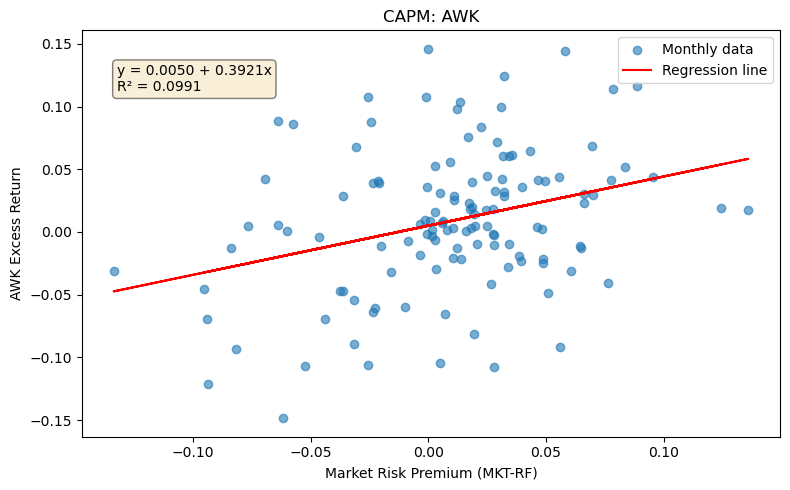


CAPM RESULTS: CVE
                            OLS Regression Results                            
Dep. Variable:                CVE_ERP   R-squared:                       0.273
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     46.11
Date:                Sun, 10 May 2026   Prob (F-statistic):           4.22e-10
Time:                        02:18:12   Log-Likelihood:                 76.903
No. Observations:                 125   AIC:                            -149.8
Df Residuals:                     123   BIC:                            -144.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0039      0.012 

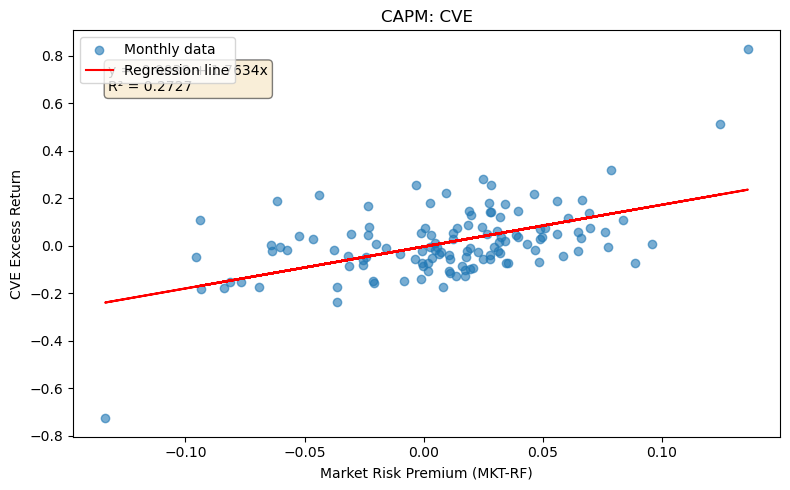


CAPM RESULTS: DG
                            OLS Regression Results                            
Dep. Variable:                 DG_ERP   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.029
Method:                 Least Squares   F-statistic:                     4.722
Date:                Sun, 10 May 2026   Prob (F-statistic):             0.0317
Time:                        02:18:12   Log-Likelihood:                 137.29
No. Observations:                 125   AIC:                            -270.6
Df Residuals:                     123   BIC:                            -264.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0034      0.007  

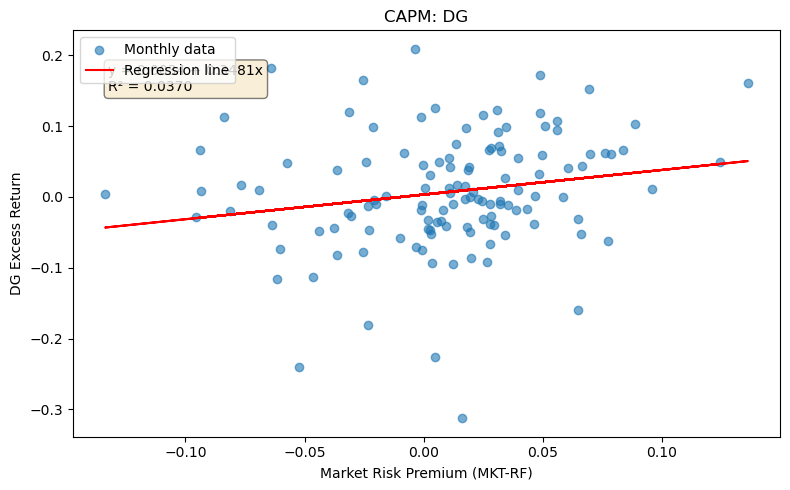


CAPM RESULTS: ES
                            OLS Regression Results                            
Dep. Variable:                 ES_ERP   R-squared:                       0.138
Model:                            OLS   Adj. R-squared:                  0.131
Method:                 Least Squares   F-statistic:                     19.69
Date:                Sun, 10 May 2026   Prob (F-statistic):           2.00e-05
Time:                        02:18:12   Log-Likelihood:                 191.00
No. Observations:                 125   AIC:                            -378.0
Df Residuals:                     123   BIC:                            -372.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.005  

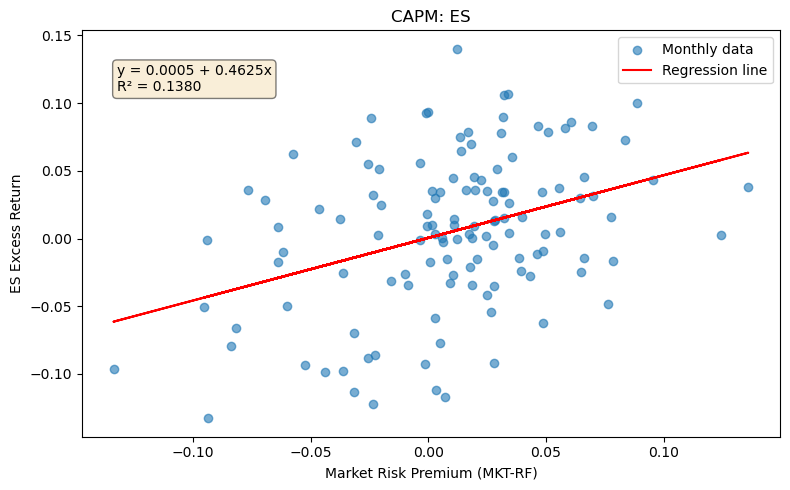


CAPM RESULTS: EXPE
                            OLS Regression Results                            
Dep. Variable:               EXPE_ERP   R-squared:                       0.348
Model:                            OLS   Adj. R-squared:                  0.343
Method:                 Least Squares   F-statistic:                     65.78
Date:                Sun, 10 May 2026   Prob (F-statistic):           4.34e-13
Time:                        02:18:12   Log-Likelihood:                 116.37
No. Observations:                 125   AIC:                            -228.7
Df Residuals:                     123   BIC:                            -223.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0028      0.009

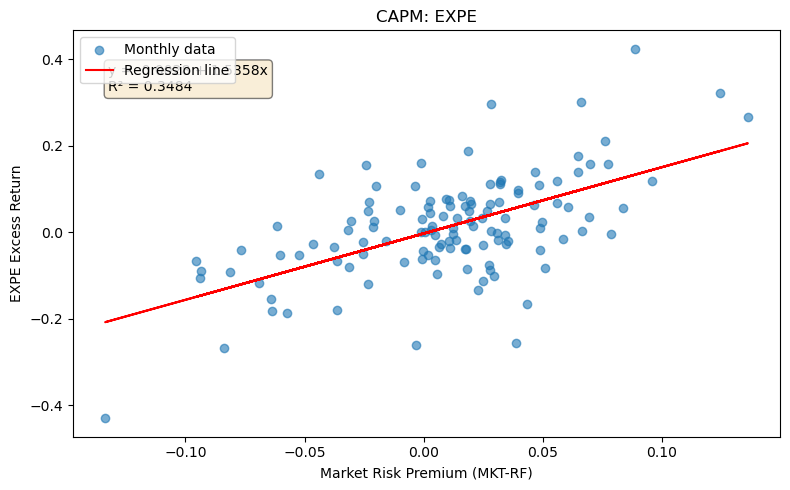


CAPM RESULTS: HUBB
                            OLS Regression Results                            
Dep. Variable:               HUBB_ERP   R-squared:                       0.413
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                     86.54
Date:                Sun, 10 May 2026   Prob (F-statistic):           6.52e-16
Time:                        02:18:12   Log-Likelihood:                 177.49
No. Observations:                 125   AIC:                            -351.0
Df Residuals:                     123   BIC:                            -345.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0038      0.005

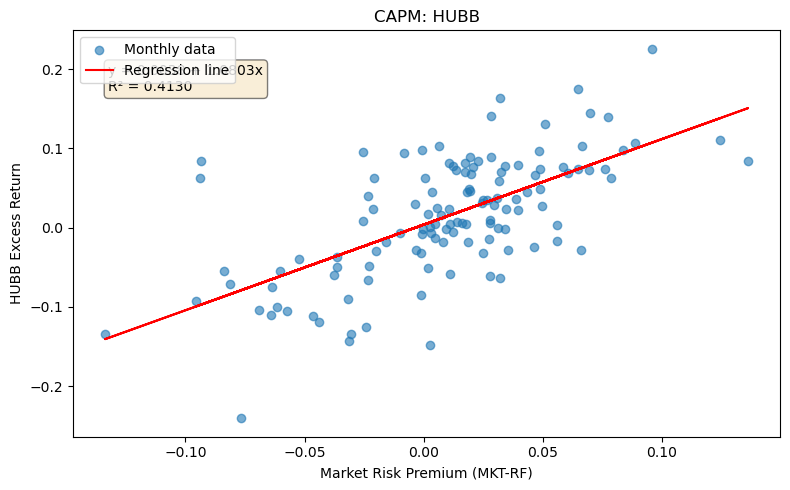


CAPM RESULTS: KHC
                            OLS Regression Results                            
Dep. Variable:                KHC_ERP   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.092
Method:                 Least Squares   F-statistic:                     13.59
Date:                Sun, 10 May 2026   Prob (F-statistic):           0.000339
Time:                        02:18:13   Log-Likelihood:                 149.86
No. Observations:                 125   AIC:                            -295.7
Df Residuals:                     123   BIC:                            -290.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0098      0.007 

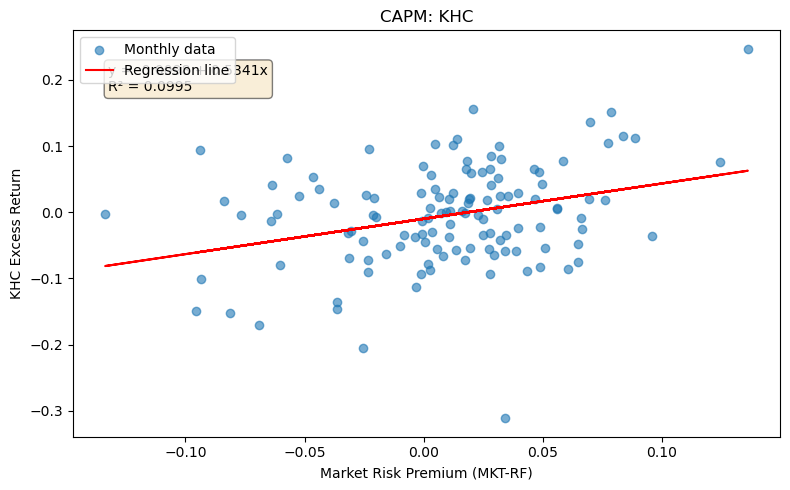


CAPM RESULTS: NTRS
                            OLS Regression Results                            
Dep. Variable:               NTRS_ERP   R-squared:                       0.505
Model:                            OLS   Adj. R-squared:                  0.501
Method:                 Least Squares   F-statistic:                     125.5
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.65e-20
Time:                        02:18:13   Log-Likelihood:                 190.71
No. Observations:                 125   AIC:                            -377.4
Df Residuals:                     123   BIC:                            -371.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0039      0.005

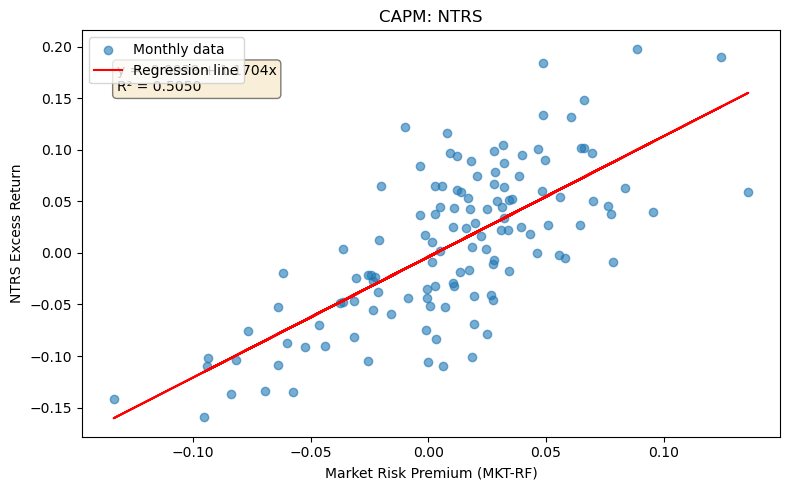


CAPM RESULTS: STZ
                            OLS Regression Results                            
Dep. Variable:                STZ_ERP   R-squared:                       0.216
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                     33.95
Date:                Sun, 10 May 2026   Prob (F-statistic):           4.64e-08
Time:                        02:18:13   Log-Likelihood:                 171.74
No. Observations:                 125   AIC:                            -339.5
Df Residuals:                     123   BIC:                            -333.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0041      0.006 

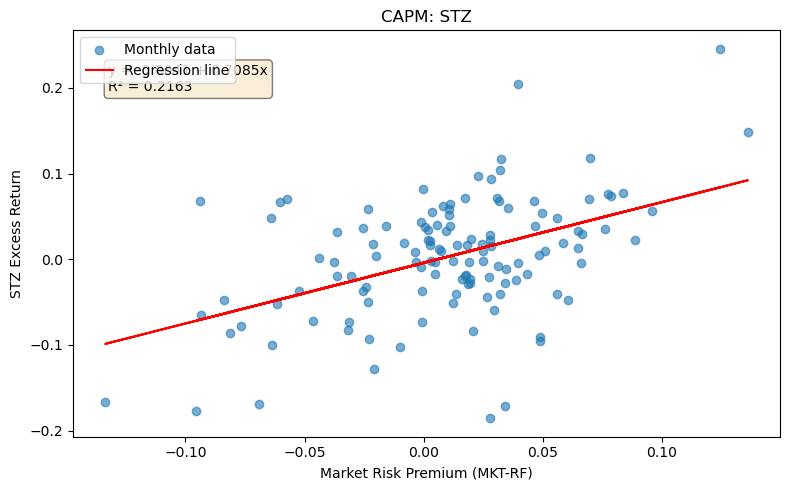


CAPM RESULTS: WTW
                            OLS Regression Results                            
Dep. Variable:                WTW_ERP   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.287
Method:                 Least Squares   F-statistic:                     50.99
Date:                Sun, 10 May 2026   Prob (F-statistic):           7.10e-11
Time:                        02:18:13   Log-Likelihood:                 198.57
No. Observations:                 125   AIC:                            -393.1
Df Residuals:                     123   BIC:                            -387.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0021      0.005 

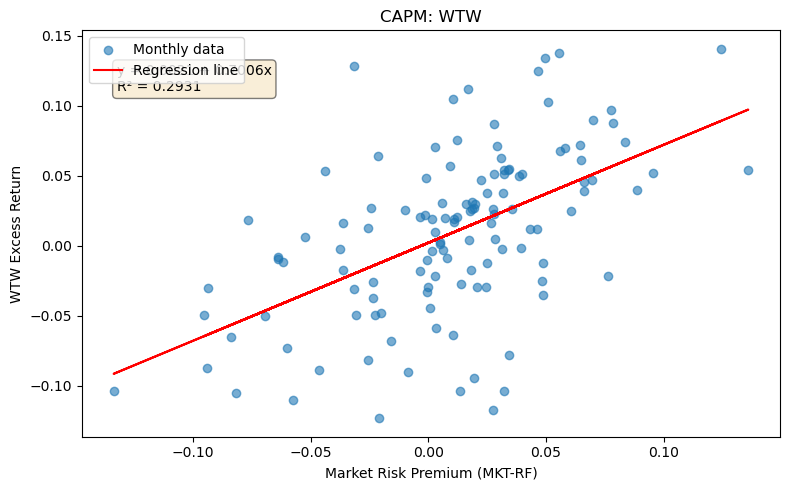


CAPM RESULTS: Equal Weight Portfolio
                            OLS Regression Results                            
Dep. Variable:          Portfolio_ERP   R-squared:                       0.671
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     250.6
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.84e-31
Time:                        02:18:13   Log-Likelihood:                 271.08
No. Observations:                 125   AIC:                            -538.2
Df Residuals:                     123   BIC:                            -532.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

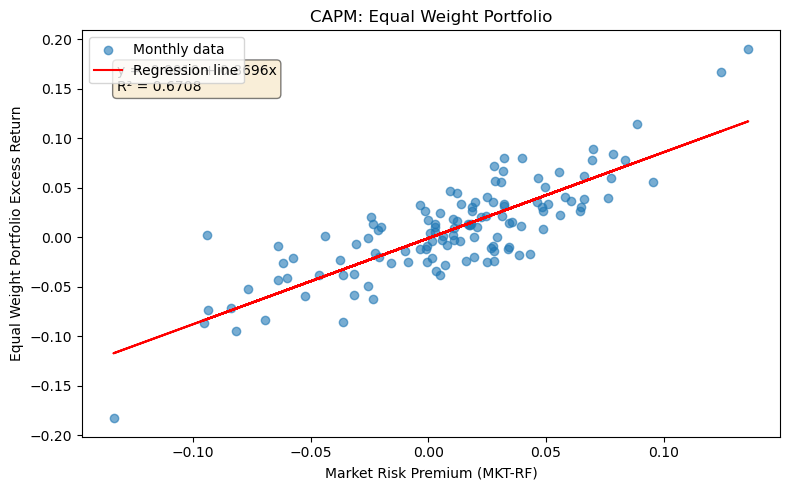

In [10]:
def run_capm(y, x, name):
    X = sm.add_constant(x)
    model = sm.OLS(y, X).fit()
    
    # Print the full regression table
    print("\n" + "="*50)
    print(f"CAPM RESULTS: {name}")
    print("="*50)
    print(model.summary())
    
    alpha = model.params["const"]
    beta = model.params[x.name]
    print(f"\nEquation: {name}_ERP = {alpha:.4f} + {beta:.4f} * MKT_RF")
    print(f"R-squared: {model.rsquared:.4f}")
    
    # Scatter plot with regression line
    plt.figure(figsize=(8, 5))
    plt.scatter(x, y, alpha=0.6, label="Monthly data")
    plt.plot(x, model.predict(X), color="red", label="Regression line")
    plt.title(f"CAPM: {name}")
    plt.xlabel("Market Risk Premium (MKT-RF)")
    plt.ylabel(f"{name} Excess Return")
    plt.legend()
    equation_text = f"y = {alpha:.4f} + {beta:.4f}x\nR² = {model.rsquared:.4f}"
    plt.annotate(equation_text, xy=(0.05, 0.85), xycoords='axes fraction', fontsize=10,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    plt.tight_layout()
    plt.show()
    
    return model

# MKT_RF series to use as X in all regressions
x_var = final_data["MKT_RF"].rename("MKT_RF")

# Run for each stock
results = {}
for t in tickers:
    y_var = final_data[t + "_ERP"]
    results[t] = run_capm(y_var, x_var, t)

# Run for the portfolio
portfolio_model = run_capm(final_data["Portfolio_ERP"], x_var, "Equal Weight Portfolio")

In [11]:
# Build a summary table of all CAPM regression results
all_tickers = tickers + ["Equal Weight Portfolio"]
all_models = list(results.values()) + [portfolio_model]

summary_rows = []
for name, model in zip(all_tickers, all_models):
    row = {
        "Stock/Portfolio": name,
        "Alpha (Intercept)": round(model.params["const"], 6),
        "Beta (MKT-RF)": round(model.params["MKT_RF"], 6),
        "R-Squared": round(model.rsquared, 6),
        "Alpha p-value": round(model.pvalues["const"], 6),
        "Beta p-value": round(model.pvalues["MKT_RF"], 6),
        "Alpha Std Error": round(model.bse["const"], 6),
        "Beta Std Error": round(model.bse["MKT_RF"], 6),
        "Observations": int(model.nobs),
    }
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

# Add to the existing Excel workbook as a new sheet
with pd.ExcelWriter(output_path, engine="openpyxl", mode="a") as writer:
    df_summary.to_excel(writer, sheet_name="Regression Summary", index=False)

print("Regression Summary sheet added to", output_path)
print(df_summary)

Regression Summary sheet added to Mehrukh_Hassan.xlsx
           Stock/Portfolio  Alpha (Intercept)  Beta (MKT-RF)  R-Squared  \
0                      AWK           0.005000       0.392055   0.099147   
1                      CVE          -0.003927       1.763369   0.272683   
2                       DG           0.003378       0.348083   0.036974   
3                       ES           0.000481       0.462514   0.137987   
4                     EXPE          -0.002850       1.535795   0.348433   
5                     HUBB           0.003794       1.080319   0.413012   
6                      KHC          -0.009820       0.534056   0.099509   
7                     NTRS          -0.003878       1.170440   0.505049   
8                      STZ          -0.004118       0.708492   0.216304   
9                      WTW           0.002072       0.700554   0.293065   
10  Equal Weight Portfolio          -0.000987       0.869568   0.670808   

    Alpha p-value  Beta p-value  Alpha Std Er

In [12]:
import os

print("=" * 50)
print("VERIFICATION REPORT")
print("=" * 50)

# 1. Check working directory
print(f"\n📁 Working folder: {os.getcwd()}")

# 2. Check Excel file exists
if os.path.exists(output_path):
    print(f"✅ Excel file found: {output_path}")
else:
    print(f"❌ Excel file NOT found: {output_path}")

# 3. Check all Excel sheets
from openpyxl import load_workbook
wb = load_workbook(output_path)
expected_sheets = ["WRDS Data", "Monthly Prices", "Monthly Returns", "Excess Returns", "Regression Summary"]
print(f"\n📊 Excel sheets found: {wb.sheetnames}")
for sheet in expected_sheets:
    if sheet in wb.sheetnames:
        print(f"  ✅ '{sheet}' sheet present")
    else:
        print(f"  ❌ '{sheet}' sheet MISSING")

# 4. Check Fama-French data
print(f"\n📈 Fama-French data:")
print(f"  Rows: {len(df_factors)} (should be ~132)")
print(f"  Columns: {list(df_factors.columns)} (should be Date, Mkt-RF, RF)")
print(f"  Date range: {df_factors['Date'].min()} to {df_factors['Date'].max()}")

# 5. Check stock prices
print(f"\n💰 Monthly Prices:")
print(f"  Months downloaded: {len(prices)} (should be ~132)")
print(f"  Tickers: {list(prices.columns)}")
missing = prices.isnull().sum()
if missing.sum() == 0:
    print(f"  ✅ No missing price data")
else:
    print(f"  ⚠️ Missing values per ticker:")
    print(missing[missing > 0])

# 6. Check returns
print(f"\n📉 Monthly Returns:")
print(f"  Rows: {len(returns)} (should be ~131)")
print(f"  Portfolio column present: {'Portfolio' in returns.columns}")

# 7. Check ERPs
print(f"\n📊 Excess Returns (ERPs):")
print(f"  Rows: {len(final_data)} (should be ~131)")
erp_cols = [t + "_ERP" for t in tickers] + ["Portfolio_ERP"]
for col in erp_cols:
    if col in final_data.columns:
        print(f"  ✅ {col} present")
    else:
        print(f"  ❌ {col} MISSING")

# 8. Check regressions
print(f"\n📐 Regressions:")
for t in tickers:
    if t in results:
        alpha = round(results[t].params["const"], 4)
        beta = round(results[t].params["MKT_RF"], 4)
        r2 = round(results[t].rsquared, 4)
        print(f"  ✅ {t}: alpha={alpha}, beta={beta}, R²={r2}")
    else:
        print(f"  ❌ {t} regression MISSING")

port_alpha = round(portfolio_model.params["const"], 4)
port_beta = round(portfolio_model.params["MKT_RF"], 4)
port_r2 = round(portfolio_model.rsquared, 4)
print(f"  ✅ Portfolio: alpha={port_alpha}, beta={port_beta}, R²={port_r2}")

print("\n" + "=" * 50)
print("If all items show ✅ you are ready to submit!")
print("=" * 50)

VERIFICATION REPORT

📁 Working folder: /Users/mehrukhhassan/FIN
✅ Excel file found: Mehrukh_Hassan.xlsx

📊 Excel sheets found: ['WRDS Data', 'Monthly Prices', 'Monthly Returns', 'Excess Returns', 'Regression Summary']
  ✅ 'WRDS Data' sheet present
  ✅ 'Monthly Prices' sheet present
  ✅ 'Monthly Returns' sheet present
  ✅ 'Excess Returns' sheet present
  ✅ 'Regression Summary' sheet present

📈 Fama-French data:
  Rows: 132 (should be ~132)
  Columns: ['Date', 'Mkt-RF', 'RF'] (should be Date, Mkt-RF, RF)
  Date range: 2015-01-30 00:00:00 to 2025-12-31 00:00:00

💰 Monthly Prices:
  Months downloaded: 132 (should be ~132)
  Tickers: ['AWK', 'CVE', 'DG', 'ES', 'EXPE', 'HUBB', 'KHC', 'NTRS', 'STZ', 'WTW']
  ⚠️ Missing values per ticker:
Ticker
KHC    6
dtype: int64

📉 Monthly Returns:
  Rows: 125 (should be ~131)
  Portfolio column present: True

📊 Excess Returns (ERPs):
  Rows: 125 (should be ~131)
  ✅ AWK_ERP present
  ✅ CVE_ERP present
  ✅ DG_ERP present
  ✅ ES_ERP present
  ✅ EXPE_ERP pr